# Penguin Colony Density & Count Prediction
## Utilising the Windchill Model of Winterl et al. (2024)

**Reference:** Winterl, A. et al. (2024). Remote sensing of emperor penguin abundance and breeding success. *Nature Communications*, 15, 4419. https://doi.org/10.1038/s41467-024-48239-8

---

## Background

Emperor penguin colony counts from SAR imagery require converting colony **area** (m²) into **number of individuals**. This requires knowledge of the colony **density** (penguins/m²), which varies continuously with weather:  penguins huddle tightly in cold, windy, dark conditions and spread out in warm, calm, bright conditions.

Winterl et al. (2024) developed a **windchill model** that predicts colony density from four meteorological variables:
- Air temperature (K)
- Wind speed (m/s)
- Solar radiation (W/m²)
- Relative humidity (%)

Rather than rerunning the PyMC model, we have simplified the approach to use the reported coefficients for each weather variable. 

# In this version - We are adding a negative sign between np.exp(-(cT*T + xxyy)

---

That makes the data make sense, so that is what we will do. 


We are then moving forward and redoing all of the analysis in each notebook with the new outputs. 


## Simple approach to  the density model

If we just use the mean values of the parameters (cT, cW, cR, cH, Tc), reported in Winterl et al. 2024 and plug them in the windchill formula:

rho_pred = rho_max/(1 + exp-(( cT*T + cW*W + cH*H + cR*R - Tc ))  )

with:
rho_max = 12.83 1/m²
T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

Then use rho_pred and area A to predict the number of individuals

count_pred = rho_pred * A



###  Supplementary Table 3 (Winterl et al. 2024)
The table contains the numerical values for the best estimate of the windchill model
parameters.  

|      |   cT     |    cW     |     cR       |     cH    |       Tc     |      sigma |
|------|----------|-----------|--------------|-----------|--------------|------------| 
| mean |-0.023845 | 0.079986  | -0.000767    | 0.008434  |   -4.903825  |    0.731349| 
| std  | 0.003476 |  0.007152 |   0.000133   | 0.001784  |    0.909726  |    0.023509|


# Assessing model performance 

To determine if I have taken the correct approach to running this model, I have referenced back to the analysis run for the 2024 paper: 

Tracking Wintertime Behaviour of Emperor Penguins Using High-Resolution Synthetic Aperture Radar Imagery
LaRue et al., 2026 https://doi.org/10.1002/rse2.70083

Alex used his model to analyse winter SAR imagery. To check how my model development compared to his output, I anlaysed Michelles 2024 data and compared that to his results. 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [2]:
#Ok so we want to follow what Alex suggested in the simple approach 

#Plug in the mean values into the windchill formula, skipping all of the bayesian (depreciated package) dramas. 

#We take our weather values, his mean density coefficient values, and rho max to combine with the areas to give a count. 

#|      |   cT     |    cW     |     cR       |     cH    |       Tc     |      sigma |
#|------|----------|-----------|--------------|-----------|--------------|------------| 
#| mean |-0.023845 | 0.079986  | -0.000767    | 0.008434  |   -4.903825  |    0.731349| 
#| std  | 0.003476 |  0.007152 |   0.000133   | 0.001784  |    0.909726  |    0.023509|


cT = -0.023845 
cW = 0.079986 
cR = -0.000767 
cH = 0.008434 
Tc = -4.903825 
sigma = 0.731349
#rho_max = 12.83

# Posterior SDs from convergence diagnostics table
sd_T  = 0.003476
sd_W  = 0.007152
sd_R  = 0.000133
sd_H  = 0.001784
sd_Tc = 0.909726


In [6]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

#I have three different data sources that needed this model to be run on: our 2025 data, Michelle's 2024 data, and the 2025 VHR data for the Ross Sea colonies

dfRFD = pd.read_csv(
    os.path.join(INPUTPATH, "Final data files/SAR_datav2_ERA5_v7_cleaned.csv")
).drop(columns="Unnamed: 0")

dfMLR = pd.read_csv(
    os.path.join(INPUTPATH, "Final data files/sar_huddles_20250502_ERA5_v3_grouped_era5added.csv"))# "sar_huddles_20250502_ERA5_v3_grouped.xlsx")
#).drop(columns="Unnamed: 0")

dfVHR = pd.read_excel(
    os.path.join(INPUTPATH, "VHR_RossSea2025_area-data_v1.xlsx")
)


In [7]:
rP = 0.3 / 2
rho_max = (np.pi / 2 / 3**0.5) / (rP**2 * np.pi)
print(f"Maximum packing density (rho_max): {rho_max:.2f} penguins/m²")

Maximum packing density (rho_max): 12.83 penguins/m²


# First running it on Michelle's 2024 SAR data 

dfMLR

In [8]:
#Weather data from Michelle's 2024 data
T = dfMLR["temp_airK"].values
W = dfMLR["met_ff10"].values
R = dfMLR["met_rad"].values
H = dfMLR["met_humc"].values

In [9]:
#Plug them in the windchill formula
#ADDING A NEGATIVE SIGN 
#rho_pred = rho_max/(1 + exp(-( cT*T + cW*W + cH*H + cR*R - Tc )))

#with:
#rho_max = 12.83 1/m²
#T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

#Then use rho_pred and area A to predict the number of individuals:
#count_pred = rho_pred * A


rho_pred = rho_max/(1 + np.exp(-((cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc )))


In [10]:
#And now we take that rho pred and mutliply it by area to get our count estimates

area_m2 = dfMLR["area_m2"].values

count_pred = rho_pred * area_m2

In [11]:

# Add to dataframe
dfMLR["rho_pred"] = rho_pred
dfMLR["count_pred"] = count_pred

# Export
dfMLR.to_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfMLR_with_predictions_final_July2026.csv"), index=False)
print(f"Exported {len(dfMLR)} rows to dfMLR_with_predictions_final_July2026.csv")
print(dfMLR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))

Exported 73 rows to dfMLR_with_predictions_final_July2026.csv
      colony        date  rho_pred  count_pred
1   Atka Bay  12/04/2024      8.53    13308.62
2   Atka Bay  24/04/2024      7.79    19879.10
3   Atka Bay  29/04/2024      6.69     4947.58
4   Atka Bay   9/05/2024      6.07    19863.07
5   Atka Bay  24/05/2024      6.35    13191.73
6   Atka Bay   7/06/2024      6.49    14606.38
7   Atka Bay  19/06/2024      6.73     9093.79
8   Atka Bay  25/06/2024      6.19     7373.74
9   Atka Bay  12/07/2024      7.55     8002.93
10  Atka Bay   7/08/2024      6.50     7393.15


In [12]:
# Propogating uncertainty in our estimates using the reported SD 

#To do this we want to move the value either towards or away from 0, either weakening or increasing its strength and therefore creating the upper and lower predicted density bounds 

# Simple uncertainty — propagate SDs as ± 1 standard deviation

# Lower rho — minimise exponent by pushing coefficients toward zero, decreasing strength of variable
exponent_lower = (
    (cT + sd_T) * T +   # cT negative, add SD moves toward zero
    (cW - sd_W) * W +   # cW positive, subtract SD moves toward zero
    (cR + sd_R) * R +   # cR negative, add SD moves toward zero
    (cH - sd_H) * H -   # cH positive, subtract SD moves toward zero
    (Tc + sd_Tc)         # Tc negative, add SD moves toward zero
)

# Upper rho — maximise exponent by pushing coefficients away from zero, increasing strength of variable
exponent_upper = (
    (cT - sd_T) * T +   # cT negative, subtract SD moves away from zero
    (cW + sd_W) * W +   # cW positive, add SD moves away from zero
    (cR - sd_R) * R +   # cR negative, subtract SD moves away from zero
    (cH + sd_H) * H -   # cH positive, add SD moves away from zero
    (Tc - sd_Tc)         # Tc negative, subtract SD moves away from zero
)

dfMLR["rho_upper"] = rho_max / (1 + np.exp(-(exponent_upper)))
dfMLR["rho_lower"] = rho_max / (1 + np.exp(-(exponent_lower)))



# Verify
print(f"\nrho_pred mean:  {dfMLR['rho_pred'].mean():.4f}")
print(f"rho_lower mean: {dfMLR['rho_lower'].mean():.4f}")
print(f"rho_upper mean: {dfMLR['rho_upper'].mean():.4f}")
print(f"\nContribution of each SD to exponent:")
print(f"  sd_T × mean_T:  {sd_T * dfMLR['temp_airK'].mean():.4f}")
print(f"  sd_W × mean_W:  {sd_W * dfMLR['met_ff10'].mean():.4f}")
print(f"  sd_R × mean_R:  {sd_R * dfMLR['met_rad'].mean():.4f}")
print(f"  sd_H × mean_H:  {sd_H * dfMLR['met_humc'].mean():.4f}")
print(f"  sd_Tc:          {sd_Tc:.4f}")




rho_pred mean:  6.5925
rho_lower mean: 5.8785
rho_upper mean: 7.2980

Contribution of each SD to exponent:
  sd_T × mean_T:  0.8779
  sd_W × mean_W:  0.0395
  sd_R × mean_R:  0.0000
  sd_H × mean_H:  0.1517
  sd_Tc:          0.9097


In [13]:
#This way propagates uncertainty: 
# Need to revisit this with the changed signs 

print(dfMLR.columns.tolist())
# Count predictions
dfMLR["count_pred"]  = dfMLR["rho_pred"]  * dfMLR["area_m2"]
dfMLR["count_lower"] = dfMLR["rho_lower"] * dfMLR["area_m2"]
dfMLR["count_upper"] = dfMLR["rho_upper"] * dfMLR["area_m2"]


# Apparent temperature — point estimate
dfMLR["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15

print(dfMLR[["colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))

# Reverse mapping - from dfMLR names to short names
colony_short_map = {
    "Atka Bay":        "Atka",
    "Cape Crozier":    "Crozier",
    "Cape Roget":      "Roget",
    "Cape Washington": "Washington",
    "Coulman Island":  "Coulman",
    "Franklin Island": "Franklin",
}

dfMLR["colony_name"] = dfMLR["colony"].replace(colony_short_map)

# Verify
#print(dfMLR[["colony_name", "colony"]].drop_duplicates())
print(dfMLR[["colony_name", "colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


dfMLR.to_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfMLR_with_predictions_final_July2026.csv"), index=False)


['colony', 'image_id', 'area_m2', 'phenology_est', 'lat', 'lon', 'datetime', 'date', 'time', 'b_pres', 'date_time', 'year', 'month', 'day', 'doy', 'date_utc', 'time_utc', 'ts', 'met_ff10', 'temp_airK', 'd2m', 'met_humc', 'rh_water', 'rh_ice', 'met_rad', 'rho_pred', 'count_pred', 'rho_upper', 'rho_lower']
      colony        date  rho_pred  rho_lower  rho_upper  count_pred  \
1   Atka Bay  12/04/2024     8.530      7.751      9.245   13308.622   
2   Atka Bay  24/04/2024     7.790      7.029      8.513   19879.096   
3   Atka Bay  29/04/2024     6.687      5.976      7.392    4947.579   
4   Atka Bay   9/05/2024     6.068      5.408      6.736   19863.075   
5   Atka Bay  24/05/2024     6.346      5.631      7.063   13191.728   
6   Atka Bay   7/06/2024     6.491      5.708      7.272   14606.384   
7   Atka Bay  19/06/2024     6.733      5.967      7.490    9093.790   
8   Atka Bay  25/06/2024     6.191      5.526      6.861    7373.744   
9   Atka Bay  12/07/2024     7.549      6.727 

/tmp/ipykernel_10642/3916520842.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(colonies_all))
/tmp/ipykernel_10642/3916520842.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["datetime"])
/tmp/ipykernel_10642/3916520842.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["datetime"])
/tmp/ipykernel_10642/3916520842.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a 

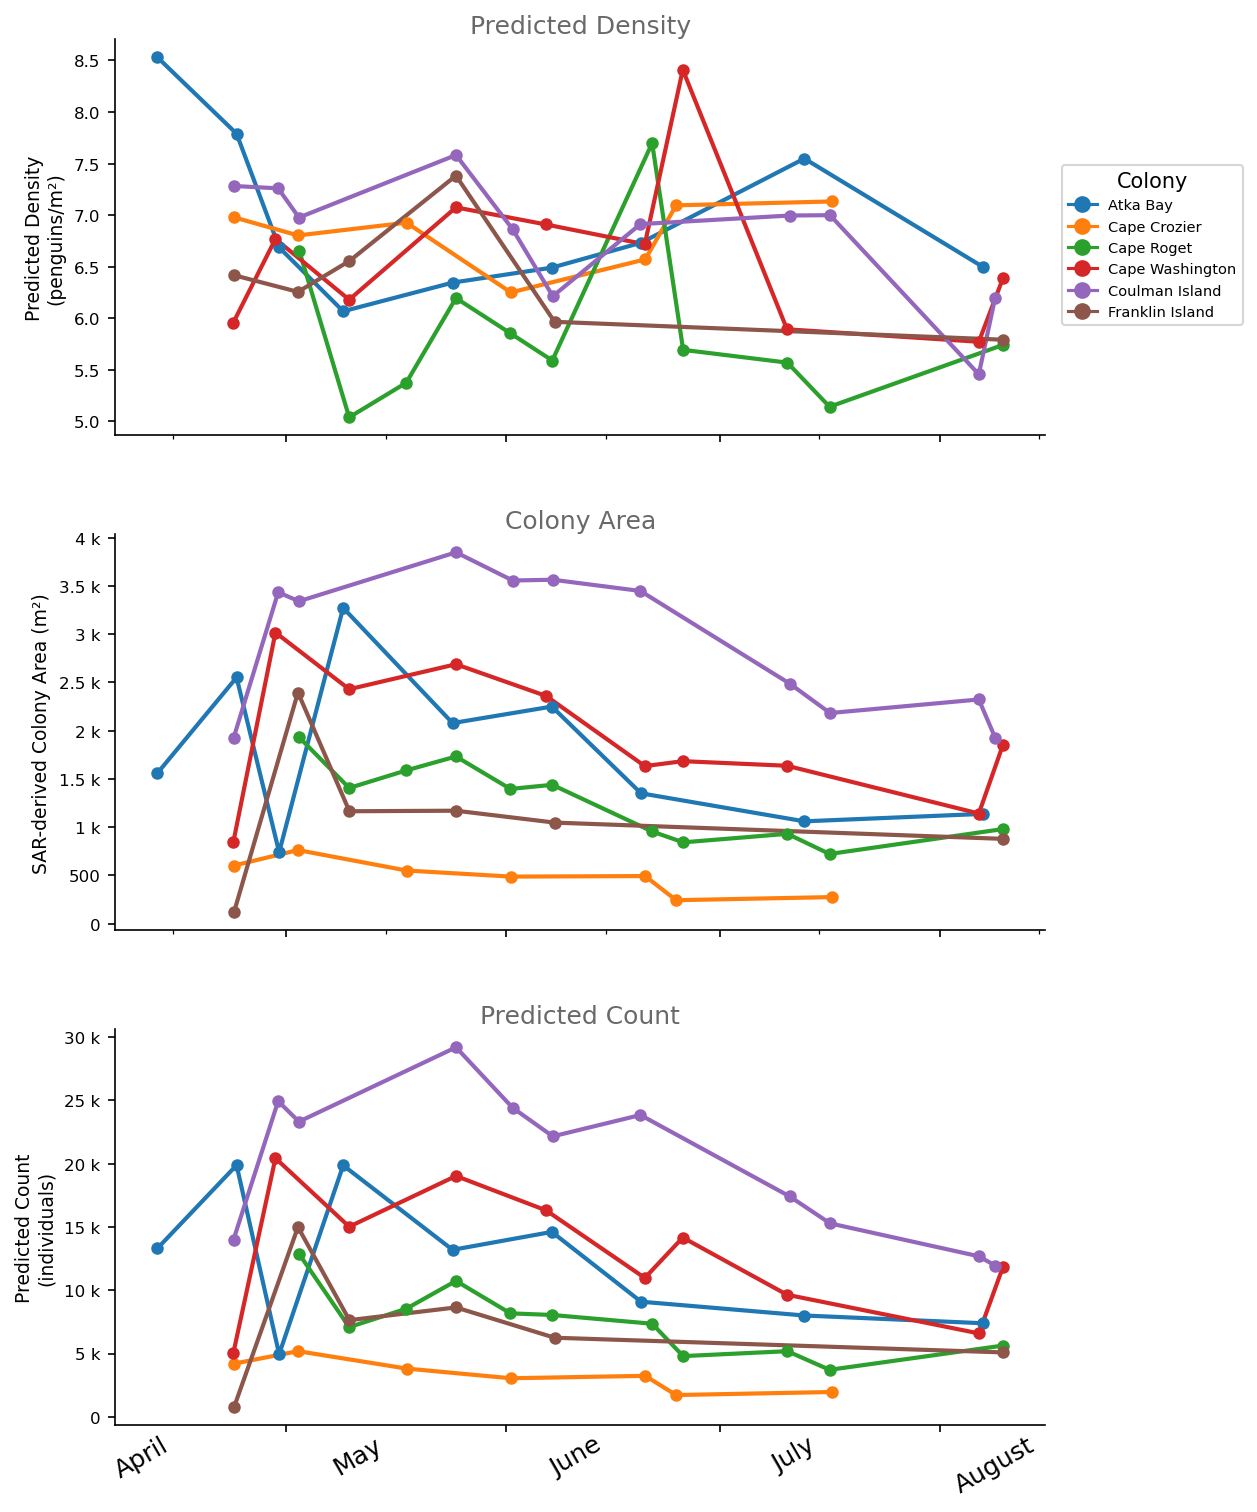

In [14]:
# Wow it worked 
#Now i wantto recreate Alex's plot to see if it matchs
import os

# ── All colonies in one figure, coloured by colony ────────────────────────────
# Three panels: area, density, count
# All colonies overlaid, coloured by colony name

# Generate colour per colony
colonies_all = sorted(dfMLR["colony"].unique())
cmap = plt.cm.get_cmap("tab20", len(colonies_all))
#colony_colors = {colony: cmap(i) for i, colony in enumerate(colonies_all)}

# ── Manual colony colours ──────────────────────────────────────────────────────
#To match Alex Winterl example
colony_colors = {
    "Atka Bay":        "#1f77b4",  # blue
    "Cape Roget":      "#2ca02c",  # green
    "Coulman Island":  "#9467bd",  # purple
    "Cape Crozier":    "#ff7f0e",  # orange
    "Cape Washington": "#d62728",  # red
    "Franklin Island": "#8c564b",  # brown
}

colonies_all = sorted(colony_colors.keys())
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for colony in colonies_all:
    df = dfMLR[dfMLR["colony"] == colony].copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime")

    if len(df) == 0:
        continue

    color = colony_colors[colony]

    # ── Panel 1: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    ax.scatter(df_a["datetime"], df_a["area_m2"],
               s=25, color=color, zorder=3, alpha=1)
    ax.plot(df_a["datetime"], df_a["area_m2"],
            color=color, linewidth=2.0, alpha=1, label=colony)

    # ── Panel 2: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["datetime"], df_d["rho_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_d["datetime"], df_d["rho_pred"],
                   s=25, color=color, zorder=3, alpha=1)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["datetime"], df_c["count_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_c["datetime"], df_c["count_pred"],
                   s=25, color=color, zorder=3, alpha=1)


# ── Formatting ─────────────────────────────────────────────────────────────────
axes[1].set_ylabel("SAR-derived Colony Area (m²)")
axes[0].set_ylabel("Predicted Density\n(penguins/m²)")
axes[2].set_ylabel("Predicted Count\n(individuals)")

axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
    ax.set_title(subtitle, fontsize=12, color="dimgrey", pad=3)
    ax.tick_params(labelsize=8)
    ax.yaxis.label.set_size(9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ── X axis formatting ──────────────────────────────────────────────────────────
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
for label in axes[2].xaxis.get_minorticklabels():
    label.set_rotation(30)
    label.set_ha("right")
    label.set_fontsize(12)
axes[2].tick_params(axis="x", which="minor", length=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
# Place legend outside the plot to avoid obscuring data
legend_handles = [
    plt.Line2D([0], [0], color=colony_colors[c], linewidth=1.5,
               marker="o", markersize=7, label=c)
    for c in colonies_all
]
axes[2].legend(handles=legend_handles,
               loc="upper left",
               bbox_to_anchor=(1.01, 3.2),
               fontsize=7, frameon=True,
               ncol=1, title="Colony")

#fig.suptitle("All Colonies — Full Season Time Series",
#             fontsize=16, fontweight="bold", y=0.99)

plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.subplots_adjust(hspace=0.25)

plt.savefig(os.path.join(INPUTPATH, "Final results/Actual final results/all_colonies_timeseries_MLR_July2026.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# 2025 SAR Data 

dfRFD

In [48]:
#Only relevant for Our 2025 data:
#For the Sabrina records we had to capture 2 images to get all subgroups of the colonies
#This code combined the observations that were captured on the same date


# Inspect Sabrina records
sabrina = dfRFD[dfRFD["colony_name"] == "Sabrina"].sort_values("ts")
print(f"Sabrina records: {len(sabrina)}")
print(sabrina[["colony_name", "ts", "DOY", "area_m2"]].to_string())

# Combine same-day Sabrina records by summing area
# Records are 1 minute apart — two SAR swaths of the same dispersed colony
sabrina_combined = dfRFD[dfRFD["colony_name"] == "Sabrina"].copy()
sabrina_combined["ts_date"] = pd.to_datetime(sabrina_combined["ts"]).dt.date

# Build agg dict dynamically using only columns that exist
agg_dict = {
    "colony_name": ("colony_name", "first"),
    "ts":          ("ts",          "first"),
    "DOY":         ("DOY",         "first"),
    "area_m2":     ("area_m2",     "sum"),
    "phenology_est":     ("phenology_est",     "first"),
    "site_id":     ("site_id",     "first"),
    "image_id":     ("image_id",     "first"),
    "date":     ("date",     "first"),
    "group":     ("group",     "first") 
}

# Add weather columns only if they exist
for col in ["temp_airK", "met_ff10", "met_rad", "met_humc"]:
    if col in sabrina_combined.columns:
        agg_dict[col] = (col, "first")

# Add any other columns that exist
for col in ["lat", "lon", "season", "month", "day"]:
    if col in sabrina_combined.columns:
        agg_dict[col] = (col, "first")

sabrina_grouped = (sabrina_combined
    .groupby("ts_date")
    .agg(**agg_dict)
    .reset_index(drop=True)
)

# Drop rows where area_m2 is NaN or zero after summing
# (both swaths had NaN area — no usable observation)
sabrina_grouped = sabrina_grouped[sabrina_grouped["area_m2"] > 0].copy()

# Replace Sabrina rows in dfArea
dfRFD = dfRFD[dfRFD["colony_name"] != "Sabrina"].copy()
dfRFD = pd.concat([dfRFD, sabrina_grouped], ignore_index=True)
dfRFD = dfRFD.sort_values(["colony_name", "ts"]).reset_index(drop=True)

print(f"\nCombined Sabrina records: {len(dfRFD[dfRFD['colony_name'] == 'Sabrina'])}")
print(dfRFD[dfRFD["colony_name"] == "Sabrina"][["ts", "DOY", "area_m2"]].to_string())

Sabrina records: 6
    colony_name                  ts  DOY     area_m2
206     Sabrina 2025-06-28 23:42:34  179  235.241029
207     Sabrina 2025-06-28 23:43:00  179  477.130937
208     Sabrina 2025-07-18 23:37:46  199  178.743672
209     Sabrina 2025-07-18 23:38:12  199  439.686114
211     Sabrina 2025-08-22 00:58:26  234         NaN
210     Sabrina 2025-08-22 00:59:06  234         NaN

Combined Sabrina records: 2
                     ts  DOY     area_m2
206 2025-06-28 23:42:34  179  712.371966
207 2025-07-18 23:37:46  199  618.429786


In [50]:
#Ok now we need to do the same thing but for our 2025 data 
#Weather data from Michelle's 2024 data
T = dfRFD["temp_airK"].values
W = dfRFD["met_ff10"].values
R = dfRFD["met_rad"].values
H = dfRFD["met_humc"].values


rho_pred = rho_max/(1 + np.exp(-((cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc )))


area_m2 = dfRFD["area_m2"].values

count_pred = rho_pred * area_m2

# Add to dataframe
dfRFD["rho_pred"] = rho_pred
dfRFD["count_pred"] = count_pred

# Export
#dfRFD.to_csv(os.path.join(INPUTPATH, "dfRFD_with_predictions_v2.csv"), index=False)
print(f"Exported {len(dfMLR)} rows to dfRFD_with_predictions.csv")
print(dfRFD[["colony_name", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))


#This way propagates uncertainty: 
# Propogating uncertainty in our estimates using the reported SD 

#To do this we want to move the value either towards or away from 0, either weakening or increasing its strength and therefore creating the upper and lower predicted density bounds 

# Simple uncertainty — propagate SDs as ± 1 standard deviation

# Lower rho — minimise exponent by pushing coefficients toward zero
exponent_lower = (
    (cT + sd_T) * T +   # cT negative, add SD moves toward zero
    (cW - sd_W) * W +   # cW positive, subtract SD moves toward zero
    (cR + sd_R) * R +   # cR negative, add SD moves toward zero
    (cH - sd_H) * H -   # cH positive, subtract SD moves toward zero
    (Tc + sd_Tc)         # Tc negative, add SD moves toward zero
)

# Upper rho — maximise exponent by pushing coefficients away from zero
exponent_upper = (
    (cT - sd_T) * T +   # cT negative, subtract SD moves away from zero
    (cW + sd_W) * W +   # cW positive, add SD moves away from zero
    (cR - sd_R) * R +   # cR negative, subtract SD moves away from zero
    (cH + sd_H) * H -   # cH positive, add SD moves away from zero
    (Tc - sd_Tc)         # Tc negative, subtract SD moves away from zero
)

dfRFD["rho_lower"] = rho_max / (1 + np.exp(-(exponent_lower)))
dfRFD["rho_upper"] = rho_max / (1 + np.exp(-(exponent_upper)))

print(dfRFD.columns.tolist())

# Verify
print(f"\nrho_pred mean:  {dfRFD['rho_pred'].mean():.4f}")
print(f"rho_lower mean: {dfRFD['rho_lower'].mean():.4f}")
print(f"rho_upper mean: {dfRFD['rho_upper'].mean():.4f}")
print(f"\nContribution of each SD to exponent:")
print(f"  sd_T × mean_T:  {sd_T * dfRFD['temp_airK'].mean():.4f}")
print(f"  sd_W × mean_W:  {sd_W * dfRFD['met_ff10'].mean():.4f}")
print(f"  sd_R × mean_R:  {sd_R * dfRFD['met_rad'].mean():.4f}")
print(f"  sd_H × mean_H:  {sd_H * dfRFD['met_humc'].mean():.4f}")
print(f"  sd_Tc:          {sd_Tc:.4f}")


# Count predictions
dfRFD["count_pred"]  = dfRFD["rho_pred"]  * dfRFD["area_m2"]
dfRFD["count_lower"] = dfRFD["rho_lower"] * dfRFD["area_m2"]
dfRFD["count_upper"] = dfRFD["rho_upper"] * dfRFD["area_m2"]


# Apparent temperature — point estimate
dfRFD["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15


print(dfRFD[["colony_name", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


dfRFD.to_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfRFD_with_predictions_final_July2026.csv"), index=False)



Exported 73 rows to dfRFD_with_predictions.csv
   colony_name       date  rho_pred  count_pred
0       Amanda 2025-04-24      6.06    17489.40
2       Amanda 2025-06-30      5.98     8947.48
3       Amanda 2025-07-22      6.09     9616.65
6     Amundsen 2025-05-25      5.47      249.45
7     Amundsen 2025-06-30      5.52      336.53
8     Amundsen 2025-07-19      5.75      246.11
11      Astrid 2025-04-25      7.99    16672.69
12      Astrid 2025-06-26      5.56     5988.50
13      Astrid 2025-06-26      5.67     6517.56
15        Atka 2025-04-28      6.23    12806.26
['colony_name', 'site_id', 'group', 'image_id', 'date', 'month', 'day', 'year', 'DOY', 'lat', 'lon', 'avg_size', 'area_m2', 'phenology_est', 'removed', 'observation(1-5)', 'grazing', 'incidence', 'azimuth', 'resolution', 'looks', 'orbit_state', 'polarization', 'slant_range', 'surface_type', 'obs', 'date_time', 'time', 'time_UTC', 'date_UTC', 'ts', 'met_ff10', 'temp_airK', 'met_humc', 'met_rad', 'd2m', 'rh_water', 'rh_ice'

/tmp/ipykernel_55344/3153647819.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfRFD[["colony_name", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))
/tmp/ipykernel_55344/3153647819.py:79: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


/tmp/ipykernel_55344/1501643857.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(colonies_all))
/tmp/ipykernel_55344/1501643857.py:95: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.88, 0.97])


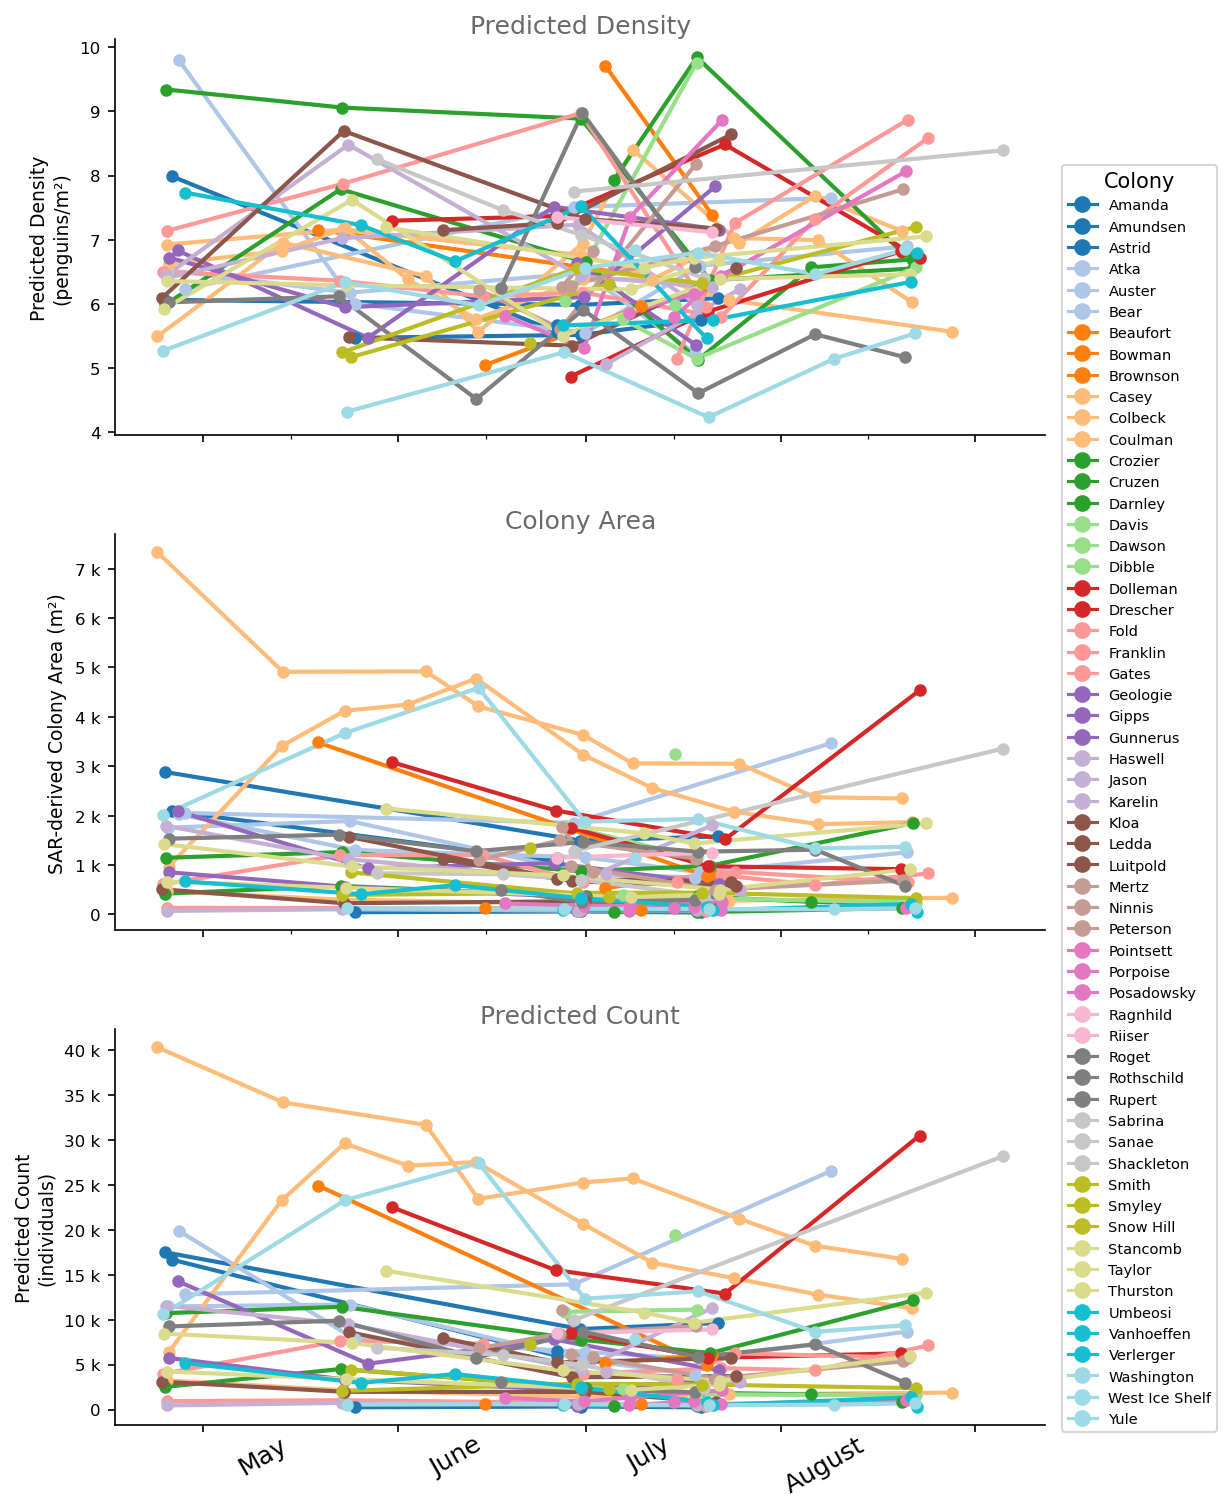

In [51]:
#Now we'll remake the figure 


import os

# ── All colonies in one figure, coloured by colony ────────────────────────────
# Three panels: area, density, count
# All colonies overlaid, coloured by colony name

# Generate colour per colony
colonies_all = sorted(dfRFD["colony_name"].unique())
cmap = plt.cm.get_cmap("tab20", len(colonies_all))
colony_colors = {colony: cmap(i) for i, colony in enumerate(colonies_all)}

colonies_all = sorted(colony_colors.keys())
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for colony in colonies_all:
    df = dfRFD[dfRFD["colony_name"] == colony].copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time")

    if len(df) == 0:
        continue

    color = colony_colors[colony]

    # ── Panel 1: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    ax.scatter(df_a["date_time"], df_a["area_m2"],
               s=25, color=color, zorder=3, alpha=1)
    ax.plot(df_a["date_time"], df_a["area_m2"],
            color=color, linewidth=2.0, alpha=1, label=colony)

    # ── Panel 2: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["date_time"], df_d["rho_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_d["date_time"], df_d["rho_pred"],
                   s=25, color=color, zorder=3, alpha=1)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["date_time"], df_c["count_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_c["date_time"], df_c["count_pred"],
                   s=25, color=color, zorder=3, alpha=1)


# ── Formatting ─────────────────────────────────────────────────────────────────
axes[1].set_ylabel("SAR-derived Colony Area (m²)")
axes[0].set_ylabel("Predicted Density\n(penguins/m²)")
axes[2].set_ylabel("Predicted Count\n(individuals)")

axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
    ax.set_title(subtitle, fontsize=12, color="dimgrey", pad=3)
    ax.tick_params(labelsize=8)
    ax.yaxis.label.set_size(9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ── X axis formatting ──────────────────────────────────────────────────────────
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
for label in axes[2].xaxis.get_minorticklabels():
    label.set_rotation(30)
    label.set_ha("right")
    label.set_fontsize(12)
axes[2].tick_params(axis="x", which="minor", length=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
# Place legend outside the plot to avoid obscuring data
legend_handles = [
    plt.Line2D([0], [0], color=colony_colors[c], linewidth=1.5,
               marker="o", markersize=7, label=c)
    for c in colonies_all
]
axes[2].legend(handles=legend_handles,
               loc="upper left",
               bbox_to_anchor=(1.01, 3.2),
               fontsize=7, frameon=True,
               ncol=1, title="Colony")


plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.subplots_adjust(hspace=0.25)

plt.savefig(os.path.join(INPUTPATH, "Final results/Actual final results/all_colonies_timeseries_RFD_simple_final-July2026.png"),
            bbox_inches="tight", dpi=150)
plt.show()

In [52]:
# ── One figure per colony ─────────────────────────────────────────────────────
output_folder = os.path.join(INPUTPATH, "Final results/Actual final results/colony_timeseries")
os.makedirs(output_folder, exist_ok=True)

colonies_all = sorted(dfRFD["colony_name"].unique())

for colony in colonies_all:
    df = dfRFD[dfRFD["colony_name"] == colony].copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time")

    if len(df) == 0:
        continue

    color = "#0072B2"

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    # ── Panel 1: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["rho_pred"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["date_time"], df_d["rho_pred"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_d["date_time"], df_d["rho_pred"],
                   s=30, color=color, zorder=3)
        # Uncertainty band
        if "rho_lower" in df_d.columns and "rho_upper" in df_d.columns:
            ax.fill_between(df_d["date_time"],
                            df_d["rho_lower"], df_d["rho_upper"],
                            color=color, alpha=0.2)

    # ── Panel 2: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_a) > 0:
        ax.plot(df_a["date_time"], df_a["area_m2"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_a["date_time"], df_a["area_m2"],
                   s=30, color=color, zorder=3)

        # avg_size reference line if available
        avg = df_a["avg_size"].dropna()
        if len(avg) > 0:
            ax.axhline(avg.iloc[0], color="gray", linewidth=1.0,
                       linestyle="--", alpha=0.7,
                       label=f"Spring baseline (avg_size = {avg.iloc[0]:,.0f} abundance index)")
            ax.legend(frameon=False, fontsize=7)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["date_time"], df_c["count_pred"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_c["date_time"], df_c["count_pred"],
                   s=30, color=color, zorder=3)
        if "count_lower" in df_c.columns and "count_upper" in df_c.columns:
            err_low  = np.maximum(df_c["count_pred"] - df_c["count_lower"], 0)
            err_high = np.maximum(df_c["count_upper"] - df_c["count_pred"], 0)
            ax.fill_between(df_c["date_time"],
                            df_c["count_pred"] - err_low,
                            df_c["count_pred"] + err_high,
                            color=color, alpha=0.2)

    # ── Formatting ─────────────────────────────────────────────────────────────
    axes[0].set_ylabel("Predicted Density\n(penguins/m²)", fontsize=9)
    axes[1].set_ylabel("Colony Area (m²)", fontsize=9)
    axes[2].set_ylabel("Predicted Count\n(individuals)", fontsize=9)

    axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
    axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

    for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
        ax.set_title(subtitle, fontsize=10, color="dimgrey", pad=3)
        ax.tick_params(labelsize=8)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # Month labels on x axis
    axes[2].xaxis.set_major_locator(mdates.MonthLocator())
    axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
    axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
    axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
    for label in axes[2].xaxis.get_minorticklabels():
        label.set_rotation(30)
        label.set_ha("right")
        label.set_fontsize(9)
    axes[2].tick_params(axis="x", which="minor", length=0)

    fig.suptitle(colony, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)

    # Save — colony name for filename
    safe_name = colony.replace(" ", "_").replace("/", "-")
    filepath = os.path.join(output_folder, f"{safe_name}_timeseries.png")
    plt.savefig(filepath, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"Saved: {safe_name}_timeseries.png")

print(f"\nDone — {len(colonies_all)} figures saved to: {output_folder}")

Saved: Amanda_timeseries.png
Saved: Amundsen_timeseries.png
Saved: Astrid_timeseries.png
Saved: Atka_timeseries.png
Saved: Auster_timeseries.png
Saved: Bear_timeseries.png
Saved: Beaufort_timeseries.png
Saved: Bowman_timeseries.png
Saved: Brownson_timeseries.png
Saved: Casey_timeseries.png
Saved: Colbeck_timeseries.png
Saved: Coulman_timeseries.png
Saved: Crozier_timeseries.png
Saved: Cruzen_timeseries.png
Saved: Darnley_timeseries.png
Saved: Davis_timeseries.png
Saved: Dawson_timeseries.png
Saved: Dibble_timeseries.png
Saved: Dolleman_timeseries.png
Saved: Drescher_timeseries.png
Saved: Fold_timeseries.png
Saved: Franklin_timeseries.png
Saved: Gates_timeseries.png
Saved: Geologie_timeseries.png
Saved: Gipps_timeseries.png
Saved: Gunnerus_timeseries.png
Saved: Haswell_timeseries.png
Saved: Jason_timeseries.png
Saved: Karelin_timeseries.png
Saved: Kloa_timeseries.png
Saved: Ledda_timeseries.png
Saved: Luitpold_timeseries.png
Saved: Mertz_timeseries.png
Saved: Ninnis_timeseries.png
Saved

# Now we want to use the same density model on the VHR Optical imagery and see what happens 

That data is stored in dfVHR dataframe as above 



In [26]:
dfVHR = pd.read_excel(
    os.path.join(INPUTPATH, "VHR_RossSea2025_area-data_v1.xlsx")
)

print(dfVHR.head())


     colony                                     image_id       lat  \
0  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
1  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
2  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
3  Franklin  25OCT24235922-P3DS-050498009010_01_P001.TIF -76.17738   
4  Colbeck   25SEP29221944-P3DS-050498011010_01_P001.TIF -77.15140   

          lon       date  time_UTC       area_m2  image_qual  \
0  169.624200 2025-09-25  00:10:27   5566.763985           3   
1  169.624200 2025-09-25  00:10:27  11426.245350           3   
2  169.624200 2025-09-25  00:10:27  16993.009330           3   
3  168.394475 2025-10-24  23:59:22   2934.939757           3   
4 -157.584100 2025-09-29  22:19:44  26896.498480           3   

                                    notes    method  ... month day  doy  \
0                 birds on top of iceberg  Set Null  ...     9  25  268   
1                        birds at colony   S

In [ ]:
T = dfVHR["temp_airK"].values
W = dfVHR["met_ff10"].values
R = dfVHR["met_rad"].values
H = dfVHR["met_humc"].values



rho_pred = rho_max/(1 + np.exp(-((cT*T) + (cW*W) + (cH*H) + (cR*R) - Tc )))


area_m2 = dfVHR["area_m2"].values

count_pred = rho_pred * area_m2

# Add to dataframe
dfVHR["rho_pred"] = rho_pred
dfVHR["count_pred"] = count_pred

# Export
#dfVHR.to_csv(os.path.join(INPUTPATH, "dfVHR_with_predictions_v2.csv"), index=False)
print(f"Exported {len(dfVHR)} rows to dfVHR_with_predictions.csv")
print(dfVHR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))


#This way propagates uncertainty: 

# Simple uncertainty — propagate SDs as ± 1 standard deviation

# Lower rho — minimise exponent by pushing coefficients toward zero
exponent_lower = (
    (cT + sd_T) * T +   # cT negative, add SD moves toward zero
    (cW - sd_W) * W +   # cW positive, subtract SD moves toward zero
    (cR + sd_R) * R +   # cR negative, add SD moves toward zero
    (cH - sd_H) * H -   # cH positive, subtract SD moves toward zero
    (Tc + sd_Tc)         # Tc negative, add SD moves toward zero
)

# Upper rho — maximise exponent by pushing coefficients away from zero
exponent_upper = (
    (cT - sd_T) * T +   # cT negative, subtract SD moves away from zero
    (cW + sd_W) * W +   # cW positive, add SD moves away from zero
    (cR - sd_R) * R +   # cR negative, subtract SD moves away from zero
    (cH + sd_H) * H -   # cH positive, add SD moves away from zero
    (Tc - sd_Tc)         # Tc negative, subtract SD moves away from zero
)

dfVHR["rho_lower"] = rho_max / (1 + np.exp(-(exponent_lower)))
dfVHR["rho_upper"] = rho_max / (1 + np.exp(-(exponent_upper)))


print(dfVHR.columns.tolist())
# Count predictions
dfVHR["count_pred"]  = dfVHR["rho_pred"]  * dfVHR["area_m2"]
dfVHR["count_lower"] = dfVHR["rho_lower"] * dfVHR["area_m2"]
dfVHR["count_upper"] = dfVHR["rho_upper"] * dfVHR["area_m2"]


# Apparent temperature — point estimate
dfVHR["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15



print(dfVHR[["colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))

dfVHR.to_csv(os.path.join(INPUTPATH, "Final results/Actual final results/dfVHR_with_predictions_final-July2026.csv"), index=False)



Exported 13 rows to dfVHR_with_predictions.csv
        colony       date  rho_pred  count_pred
0     Coulman  2025-09-25      7.60    42333.45
1     Coulman  2025-09-25      7.60    86892.92
2     Coulman  2025-09-25      7.60   129226.37
3     Franklin 2025-10-24      7.77    22798.17
4     Colbeck  2025-09-29      6.84   184094.70
5    Beaufort  2025-10-03      8.53     2374.94
6       Roget  2025-10-22      7.21    26977.12
7  Washington  2025-11-01      7.77    48952.84
8      Crozier 2025-10-10      6.77    17399.81
9     Coulman  2024-10-12      8.33   127122.06
['colony', 'image_id', 'lat', 'lon', 'date', 'time_UTC', 'area_m2', 'image_qual', 'notes', 'method', 'date_time', 'date_utc', 'time_utc', 'ts', 'year', 'month', 'day', 'doy', 'met_ff10', 'temp_airK', 'd2m', 'met_humc', 'rh_water', 'rh_ice', 'met_rad', 'rho_pred', 'count_pred', 'rho_lower', 'rho_upper']
        colony       date  rho_pred  rho_lower  rho_upper  count_pred  \
0     Coulman  2025-09-25     7.605      7.072  

/tmp/ipykernel_210525/2158759578.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfVHR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))
/tmp/ipykernel_210525/2158759578.py:46: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))
